In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [4]:
# === Load datasets ===
file_20_21 = "SP1 Season 2020-2021.csv"
file_21_22 = "SP1 Season 2021-2022.csv"
file_22_23 = "SP1 Season 2022-2023.csv"
file_23_24 = "SP1 Season 2023-2024.csv"
file_24_25 = "SP1 Season 2024-2025.csv"

df_20_21 = pd.read_csv(file_20_21)
df_21_22 = pd.read_csv(file_21_22)
df_22_23 = pd.read_csv(file_22_23)
df_23_24 = pd.read_csv(file_23_24)
df_24_25 = pd.read_csv(file_24_25)

df = pd.concat([df_20_21,df_21_22, df_22_23, df_23_24, df_24_25], ignore_index=True)

In [5]:
ar_index = df.columns.get_loc('AR')
df = df.iloc[:, :ar_index + 1]

In [6]:
df

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,SP1,12/09/2020,15:00,Eibar,Celta,0,0,D,0,0,...,1,3,17,13,3,3,4,4,1,0
1,SP1,12/09/2020,17:30,Granada,Ath Bilbao,2,0,H,0,0,...,2,2,8,10,1,2,3,4,0,0
2,SP1,12/09/2020,20:00,Cadiz,Osasuna,0,2,A,0,1,...,3,4,14,21,6,2,2,2,0,0
3,SP1,13/09/2020,13:00,Alaves,Betis,0,1,A,0,0,...,2,4,19,17,6,4,3,3,0,0
4,SP1,13/09/2020,15:00,Valladolid,Sociedad,1,1,D,1,0,...,3,2,15,17,5,3,4,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1536,SP1,24/08/2025,18:30,Villarreal,Girona,5,0,H,4,0,...,7,2,8,9,8,1,1,2,0,0
1537,SP1,24/08/2025,20:30,Oviedo,Real Madrid,0,3,A,0,1,...,3,10,8,7,1,9,2,1,0,0
1538,SP1,25/08/2025,18:30,Ath Bilbao,Vallecano,1,0,H,0,0,...,4,1,13,13,3,6,0,4,0,0
1539,SP1,25/08/2025,20:30,Sevilla,Getafe,1,2,A,1,1,...,3,6,10,24,5,3,2,2,0,0


In [7]:
df.duplicated().sum()

0

In [8]:
# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Dataset shape: (1541, 23)

First 5 rows:
   Div        Date   Time    HomeTeam    AwayTeam  FTHG  FTAG FTR  HTHG  HTAG  \
0  SP1  12/09/2020  15:00       Eibar       Celta     0     0   D     0     0   
1  SP1  12/09/2020  17:30     Granada  Ath Bilbao     2     0   H     0     0   
2  SP1  12/09/2020  20:00       Cadiz     Osasuna     0     2   A     0     1   
3  SP1  13/09/2020  13:00      Alaves       Betis     0     1   A     0     0   
4  SP1  13/09/2020  15:00  Valladolid    Sociedad     1     1   D     1     0   

   ... HST  AST  HF  AF  HC  AC  HY  AY  HR  AR  
0  ...   1    3  17  13   3   3   4   4   1   0  
1  ...   2    2   8  10   1   2   3   4   0   0  
2  ...   3    4  14  21   6   2   2   2   0   0  
3  ...   2    4  19  17   6   4   3   3   0   0  
4  ...   3    2  15  17   5   3   4   1   0   0  

[5 rows x 23 columns]

Columns: ['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', '

# Dropping Missing Values

In [9]:
df = df.dropna(axis=1)

Dropped the columns with missing values

In [10]:
df

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,SP1,12/09/2020,15:00,Eibar,Celta,0,0,D,0,0,...,1,3,17,13,3,3,4,4,1,0
1,SP1,12/09/2020,17:30,Granada,Ath Bilbao,2,0,H,0,0,...,2,2,8,10,1,2,3,4,0,0
2,SP1,12/09/2020,20:00,Cadiz,Osasuna,0,2,A,0,1,...,3,4,14,21,6,2,2,2,0,0
3,SP1,13/09/2020,13:00,Alaves,Betis,0,1,A,0,0,...,2,4,19,17,6,4,3,3,0,0
4,SP1,13/09/2020,15:00,Valladolid,Sociedad,1,1,D,1,0,...,3,2,15,17,5,3,4,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1536,SP1,24/08/2025,18:30,Villarreal,Girona,5,0,H,4,0,...,7,2,8,9,8,1,1,2,0,0
1537,SP1,24/08/2025,20:30,Oviedo,Real Madrid,0,3,A,0,1,...,3,10,8,7,1,9,2,1,0,0
1538,SP1,25/08/2025,18:30,Ath Bilbao,Vallecano,1,0,H,0,0,...,4,1,13,13,3,6,0,4,0,0
1539,SP1,25/08/2025,20:30,Sevilla,Getafe,1,2,A,1,1,...,3,6,10,24,5,3,2,2,0,0


# Data Exploration

C:\Users\Admin\AppData\Local\Temp\ipykernel_25784\4148105054.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=labels, y=counts, palette=colors)


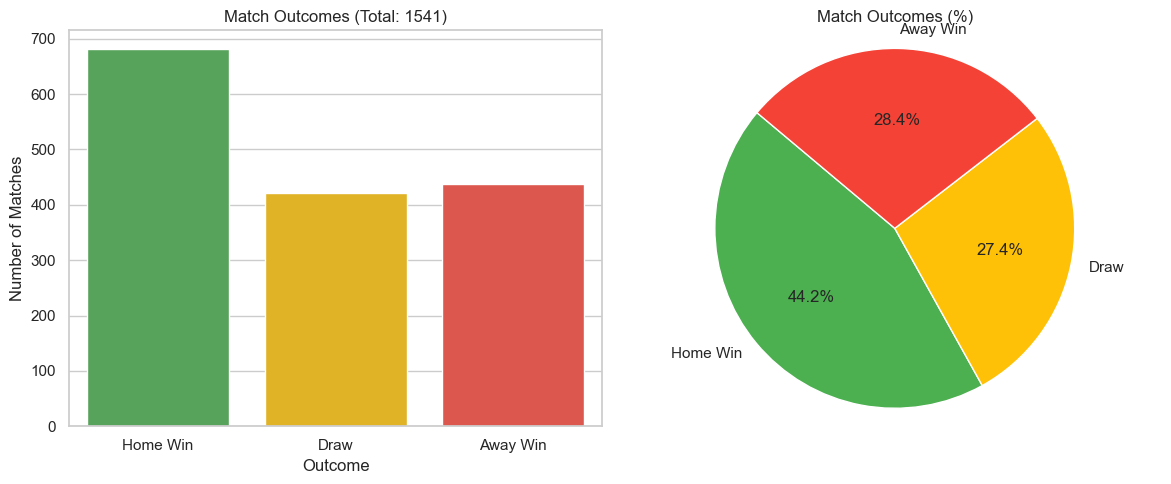

In [23]:
# Count outcomes
outcome_counts = df['FTR'].value_counts().sort_index()  # H, D, A
labels = ['Home Win', 'Draw', 'Away Win']
counts = [outcome_counts.get('H', 0), outcome_counts.get('D', 0), outcome_counts.get('A', 0)]
colors = ['#4CAF50', '#FFC107', '#F44336']
total_games = sum(counts)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.set(style="whitegrid")

# Bar Chart
sns.barplot(ax=axes[0], x=labels, y=counts, palette=colors)
axes[0].set_title(f'Match Outcomes (Total: {total_games})')
axes[0].set_ylabel('Number of Matches')
axes[0].set_xlabel('Outcome')

# Pie Chart
axes[1].pie(counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title('Match Outcomes (%)')
axes[1].axis('equal')  # Equal aspect ratio

plt.tight_layout()
plt.show()

In [24]:
# Count outcomes
outcome_counts = df['FTR'].value_counts().sort_index()  

# Rename for clarity
home_wins = outcome_counts.get('H', 0)
draws = outcome_counts.get('D', 0)
away_wins = outcome_counts.get('A', 0)
total_games = home_wins + draws + away_wins


# Print results
print(f"Total Games Played: {total_games}")
print(f"Home Wins (H): {home_wins}")
print(f"Draws (D): {draws}")
print(f"Away Wins (A): {away_wins}")

Total Games Played: 1541
Home Wins (H): 681
Draws (D): 422
Away Wins (A): 438


Overall, the data indicates that home wins are the most frequent outcome, followed by away wins, with draws being the least common.

Total Home Goals: 2206 | Average: 1.43
Total Away Goals: 1714 | Average: 1.11


C:\Users\Admin\AppData\Local\Temp\ipykernel_25784\2888079760.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Home Goals', 'Away Goals'], y=[home_goals, away_goals], palette=['#4CAF50', '#F44336'])


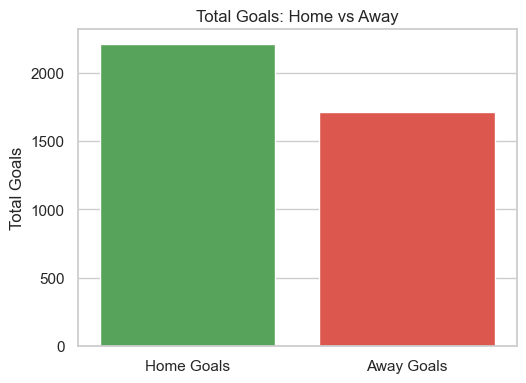

In [25]:
# Calculate totals and means
home_goals = df['FTHG'].sum()
away_goals = df['FTAG'].sum()
home_avg = df['FTHG'].mean()
away_avg = df['FTAG'].mean()

print(f"Total Home Goals: {home_goals} | Average: {home_avg:.2f}")
print(f"Total Away Goals: {away_goals} | Average: {away_avg:.2f}")

# Bar chart: total goals
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.barplot(x=['Home Goals', 'Away Goals'], y=[home_goals, away_goals], palette=['#4CAF50', '#F44336'])
plt.title('Total Goals: Home vs Away')
plt.ylabel('Total Goals')
 
plt.tight_layout()
plt.show()


Teams tend to score more goals when playing home compared to away.

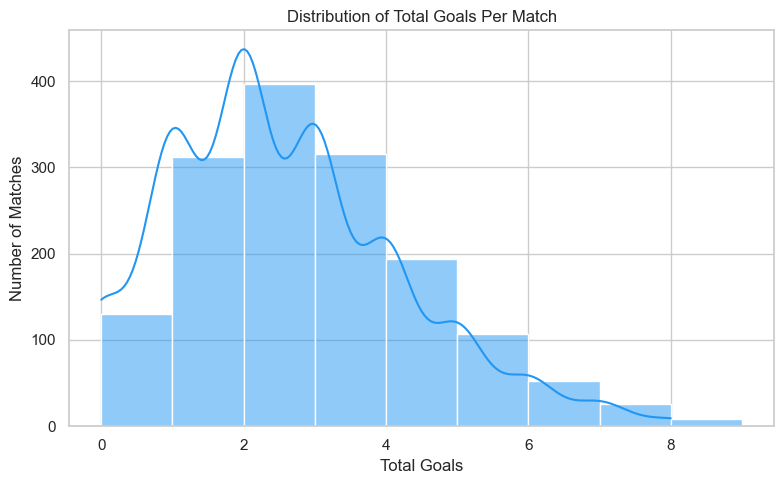

In [22]:
# Create TotalGoals column df
if "TotalGoals" not in df.columns:
    df["TotalGoals"] = df["FTHG"] + df["FTAG"]


plt.figure(figsize=(8, 5))
sns.histplot(df['TotalGoals'], bins=range(0, df['TotalGoals'].max() + 2), kde=True, color="#2196F3")
plt.title('Distribution of Total Goals Per Match')
plt.xlabel('Total Goals')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.show()

# Feature encoding

In [26]:
# Encode HomeTeam and AwayTeam
le_team = LabelEncoder()
df["HomeTeam"] = le_team.fit_transform(df["HomeTeam"])
df["AwayTeam"] = le_team.fit_transform(df["AwayTeam"])

# Encode target FTR
le_ftr = LabelEncoder()
df["FTR"] = le_ftr.fit_transform(df["FTR"])
df["HTR"] = le_ftr.fit_transform(df["HTR"])
# Typically: H=0, D=1, A=2

print("Encoding complete ")
print(df.head())

Encoding complete 
   Div        Date   Time  HomeTeam  AwayTeam  FTHG  FTAG  FTR  HTHG  HTAG  \
0  SP1  12/09/2020  15:00         8         7     0     0    1     0     0   
1  SP1  12/09/2020  17:30        13         2     2     0    2     0     0   
2  SP1  12/09/2020  20:00         6        18     0     2    0     0     1   
3  SP1  13/09/2020  13:00         0         5     0     1    0     0     0   
4  SP1  13/09/2020  15:00        24        22     1     1    1     1     0   

   ...  AST  HF  AF  HC  AC  HY  AY  HR  AR  TotalGoals  
0  ...    3  17  13   3   3   4   4   1   0           0  
1  ...    2   8  10   1   2   3   4   0   0           2  
2  ...    4  14  21   6   2   2   2   0   0           2  
3  ...    4  19  17   6   4   3   3   0   0           1  
4  ...    2  15  17   5   3   4   1   0   0           2  

[5 rows x 24 columns]


# Droping Features

In [27]:

df = df.drop(columns=["Date", "Time","Div"])

le_team = LabelEncoder()
df["HomeTeam"] = le_team.fit_transform(df["HomeTeam"])
df["AwayTeam"] = le_team.fit_transform(df["AwayTeam"])

le_ftr = LabelEncoder()
df["FTR"] = le_ftr.fit_transform(df["FTR"])
df


,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,AS,...,AST,HF,AF,HC,AC,HY,AY,HR,AR,TotalGoals
0,8,7,0,0,1,0,0,1,8,6,...,3,17,13,3,3,4,4,1,0,0
1,13,2,2,0,2,0,0,1,4,9,...,2,8,10,1,2,3,4,0,0,2
2,6,18,0,2,0,0,1,0,12,6,...,4,14,21,6,2,2,2,0,0,2
3,0,5,0,1,0,0,0,1,7,11,...,4,19,17,6,4,3,3,0,0,1
4,24,22,1,1,1,1,0,2,8,8,...,2,15,17,5,3,4,1,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1536,26,12,5,0,2,4,0,2,19,5,...,2,8,9,8,1,1,2,0,0,5
1537,19,20,0,3,0,0,1,0,6,26,...,10,8,7,1,9,2,1,0,0,3
1538,2,25,1,0,2,0,0,1,11,6,...,1,13,13,3,6,0,4,0,0,1
1539,21,11,1,2,0,1,1,1,12,9,...,6,10,24,5,3,2,2,0,0,3


# Feature importance

C:\Users\Admin\AppData\Local\Temp\ipykernel_25784\2632244322.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20_corr.values, y=top20_corr.index, palette='coolwarm')


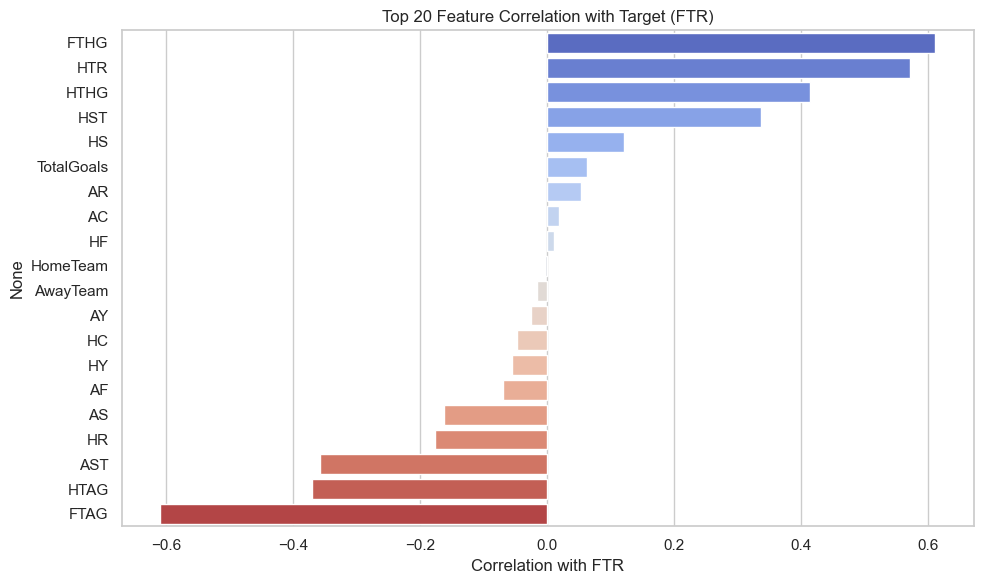

In [28]:
# Compute correlation matrix
corr_matrix = df.corr()

# Correlation of features with target
target_corr = corr_matrix['FTR'].drop('FTR').sort_values(ascending=False)

# Select top 20 features
top20_corr = target_corr.head(20)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top20_corr.values, y=top20_corr.index, palette='coolwarm')
plt.title('Top 20 Feature Correlation with Target (FTR)')
plt.xlabel('Correlation with FTR')
plt.tight_layout()
plt.show()


In [29]:
# Compute correlation with target
correlation_threshold = 0.01 
corr_matrix = df.corr()
target_corr = corr_matrix['FTR'].drop('FTR')  #Exclude target itself

# Step 2: Identify relevant features (those with correlation above threshold)
relevant_features = target_corr[abs(target_corr) >= correlation_threshold].index.tolist()

# Step 3: Keep only relevant features + target
df_selected = df[relevant_features + ['FTR']]

print(" Features retained based on correlation with FTR:")
print(relevant_features)


 Features retained based on correlation with FTR:
['AwayTeam', 'FTHG', 'FTAG', 'HTHG', 'HTAG', 'HTR', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'TotalGoals']


# Models

In [30]:
df_model = df_selected.copy()

In [31]:
X = df_model.drop("FTR", axis=1)
y = df_model["FTR"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Random model classifier

#Random model classifier is a learning model that basically operates by contsructing multiple decision trees

#reduce overfitting 

#reduces training time 

=== Random Forest Results ===
Training Accuracy: 0.9107
Testing Accuracy: 0.9061
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93        88
           1       0.97      0.71      0.82        85
           2       0.88      1.00      0.93       136

    accuracy                           0.91       309
   macro avg       0.92      0.89      0.89       309
weighted avg       0.91      0.91      0.90       309



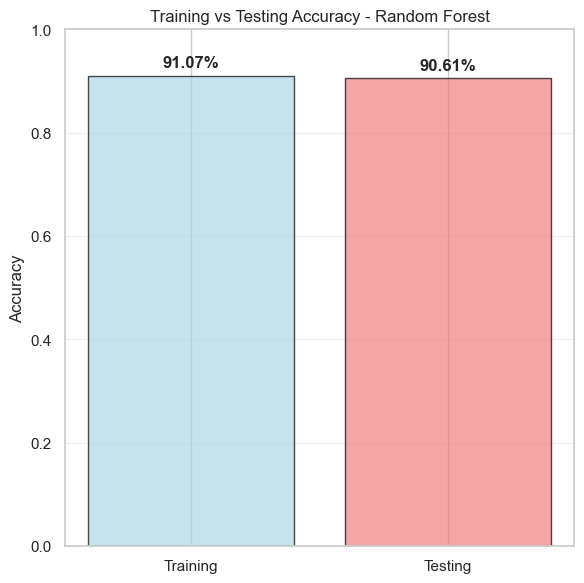

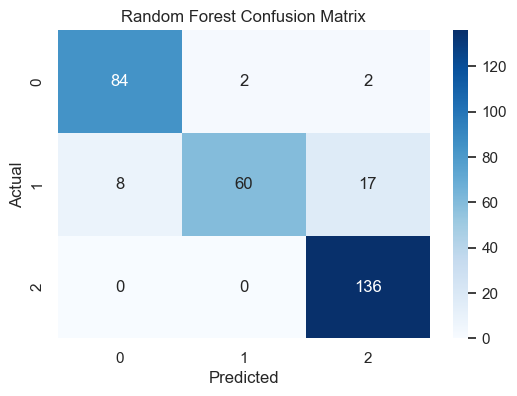

In [34]:
rf_model = RandomForestClassifier(
    n_estimators=10,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features=3,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Calculate accuracy for both training and testing with unique names
train_accuracy_rf = accuracy_score(y_train, rf_model.predict(X_train))
test_accuracy_rf = accuracy_score(y_test, rf_preds)

print("=== Random Forest Results ===")
print(f"Training Accuracy: {train_accuracy_rf:.4f}")
print(f"Testing Accuracy: {test_accuracy_rf:.4f}")
print("Classification Report:\n", classification_report(y_test, rf_preds))

# Simple bar graph for training vs testing accuracy
plt.figure(figsize=(6, 6))
accuracies_rf = [train_accuracy_rf, test_accuracy_rf]
labels = ['Training', 'Testing']
colors = ['lightblue', 'lightcoral']

bars = plt.bar(labels, accuracies_rf, color=colors, alpha=0.7, edgecolor='black')

# Add value labels on bars
for bar, accuracy in zip(bars, accuracies_rf):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f'{accuracy:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy - Random Forest')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap="Blues",
            xticklabels=le_ftr.classes_, yticklabels=le_ftr.classes_)
plt.title("Random Forest Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# support vector classifier

#support vector classifier

#permformance well when the number of fixtures is large 

#work well for linear and non linear data 


=== SVM Results ===
Training Accuracy: 0.9229
Testing Accuracy: 0.8738
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.86      0.89        88
           1       0.76      0.79      0.77        85
           2       0.91      0.93      0.92       136

    accuracy                           0.87       309
   macro avg       0.87      0.86      0.86       309
weighted avg       0.88      0.87      0.87       309



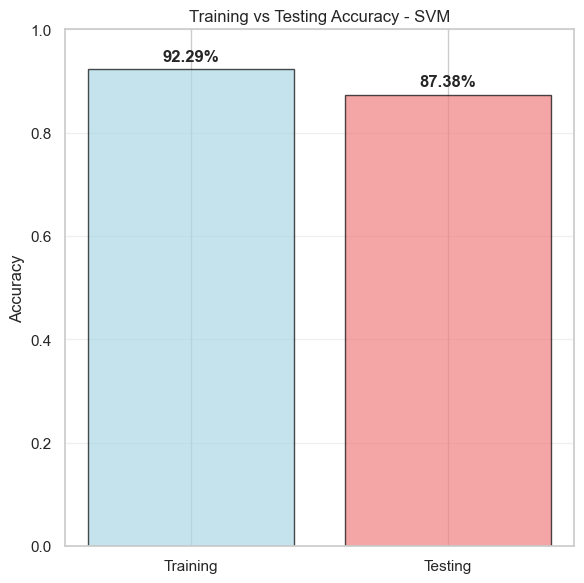

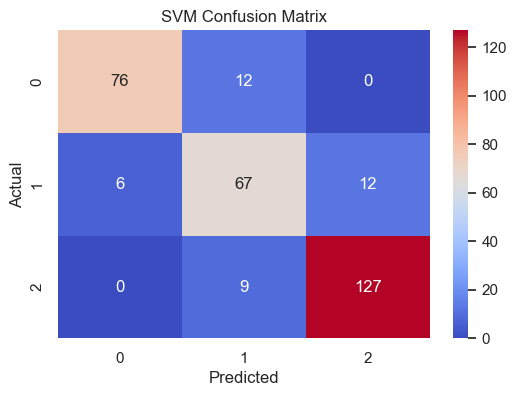

In [35]:
svm = SVC(
    C=0.3,                    # Moderate regularization
    kernel='rbf',            # Polynomial kernel
                # Quadratic
    random_state=42
)
svm.fit(X_train, y_train)
preds = svm.predict(X_test)
acc = accuracy_score(y_test, preds)

# Calculate accuracy for both training and testing with unique names
train_accuracy_svm = accuracy_score(y_train, svm.predict(X_train))
test_accuracy_svm = accuracy_score(y_test, preds)

print("\n=== SVM Results ===")
print(f"Training Accuracy: {train_accuracy_svm:.4f}")
print(f"Testing Accuracy: {test_accuracy_svm:.4f}")
print("Classification Report:\n", classification_report(y_test, preds))

# Simple bar graph for training vs testing accuracy
plt.figure(figsize=(6, 6))
accuracies_svm = [train_accuracy_svm, test_accuracy_svm]
labels = ['Training', 'Testing']
colors = ['lightblue', 'lightcoral']

bars = plt.bar(labels, accuracies_svm, color=colors, alpha=0.7, edgecolor='black')

# Add value labels on bars
for bar, accuracy in zip(bars, accuracies_svm):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f'{accuracy:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy - SVM')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap="coolwarm",
            xticklabels=le_ftr.classes_, yticklabels=le_ftr.classes_)
plt.title("SVM Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# AdaBoostClassifer model

#Improve accuracy and it focuses deficult cases

In [36]:
adaboost_model = AdaBoostClassifier(
    learning_rate=0.8,
    n_estimators=200,
    random_state=42
)
adaboost_model.fit(X_train,y_train)

AdaBoostClassifier(learning_rate=0.8, n_estimators=200, random_state=42)


=== Adaboost Results ===
Training Accuracy: 0.9310
Testing Accuracy: 0.9223
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.80      0.89        88
           1       0.79      0.99      0.88        85
           2       0.99      0.96      0.98       136

    accuracy                           0.92       309
   macro avg       0.93      0.92      0.91       309
weighted avg       0.94      0.92      0.92       309



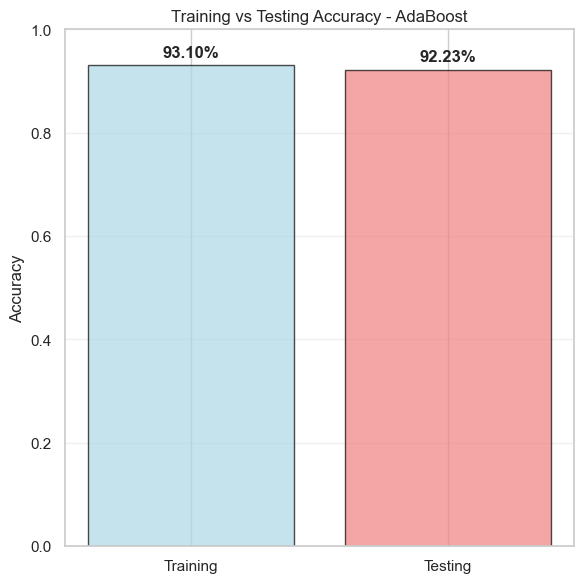

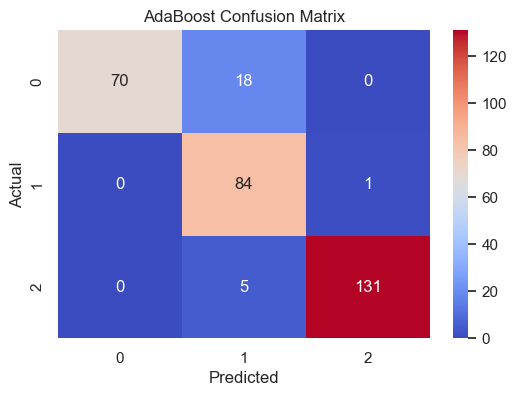

In [37]:
adaboost_model = AdaBoostClassifier(
    learning_rate=0.8,
    n_estimators=200,
    random_state=42
)
adaboost_model.fit(X_train,y_train)

y_pred_adaboost = adaboost_model.predict(X_test)

# Calculate accuracy for both training and testing with unique names
train_accuracy_adaboost = accuracy_score(y_train, adaboost_model.predict(X_train))
test_accuracy_adaboost = accuracy_score(y_test, y_pred_adaboost)

print("\n=== Adaboost Results ===")
print(f"Training Accuracy: {train_accuracy_adaboost:.4f}")
print(f"Testing Accuracy: {test_accuracy_adaboost:.4f}")
print("Classification Report:\n", classification_report(y_test,y_pred_adaboost))

# Simple bar graph for training vs testing accuracy
plt.figure(figsize=(6, 6))
accuracies_adaboost = [train_accuracy_adaboost, test_accuracy_adaboost]
labels = ['Training', 'Testing']
colors = ['lightblue', 'lightcoral']

bars = plt.bar(labels, accuracies_adaboost, color=colors, alpha=0.7, edgecolor='black')

# Add value labels on bars
for bar, accuracy in zip(bars, accuracies_adaboost):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f'{accuracy:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy - AdaBoost')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrix (fixed variable name from preds to y_pred_adaboost)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_adaboost), annot=True, fmt='d', cmap="coolwarm",
            xticklabels=le_ftr.classes_, yticklabels=le_ftr.classes_)
plt.title("AdaBoost Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# KNN Model

In [38]:
knn_clf= KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train,y_train)

KNeighborsClassifier()


=== KNN Results ===
Training Accuracy: 0.8093
Testing Accuracy: 0.7346
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.82      0.81        88
           1       0.54      0.55      0.55        85
           2       0.81      0.79      0.80       136

    accuracy                           0.73       309
   macro avg       0.72      0.72      0.72       309
weighted avg       0.74      0.73      0.74       309



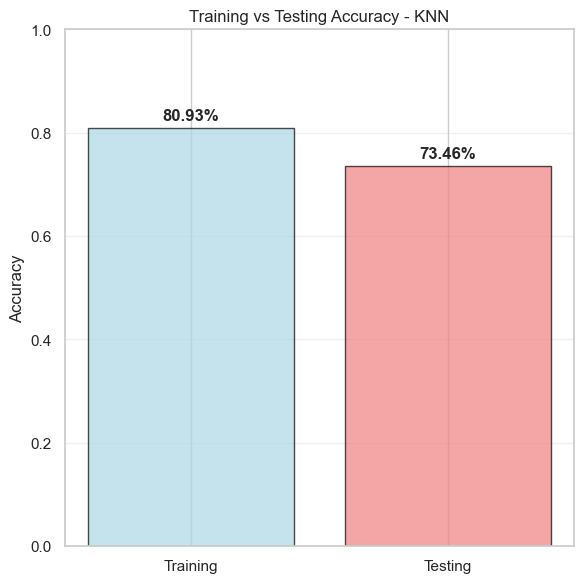

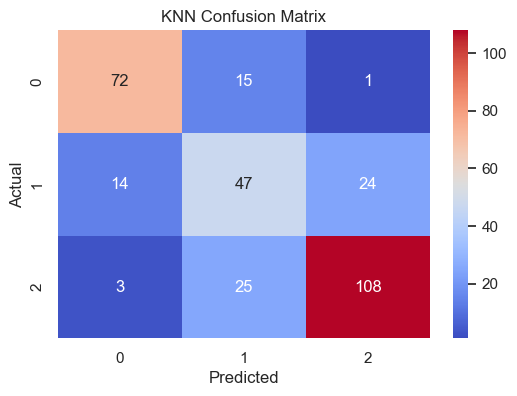

In [39]:
knn_clf= KNeighborsClassifier(n_neighbors=10)
knn_clf.fit(X_train,y_train)

y_pred_knn =knn_clf.predict(X_test)

# Calculate accuracy for both training and testing with unique names
train_accuracy_knn = accuracy_score(y_train, knn_clf.predict(X_train))
test_accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("\n=== KNN Results ===")
print(f"Training Accuracy: {train_accuracy_knn:.4f}")
print(f"Testing Accuracy: {test_accuracy_knn:.4f}")
print("Classification Report:\n", classification_report(y_test,y_pred_knn))

# Simple bar graph for training vs testing accuracy
plt.figure(figsize=(6, 6))
accuracies_knn = [train_accuracy_knn, test_accuracy_knn]
labels = ['Training', 'Testing']
colors = ['lightblue', 'lightcoral']

bars = plt.bar(labels, accuracies_knn, color=colors, alpha=0.7, edgecolor='black')

# Add value labels on bars
for bar, accuracy in zip(bars, accuracies_knn):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f'{accuracy:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy - KNN')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap="coolwarm",
            xticklabels=le_ftr.classes_, yticklabels=le_ftr.classes_)
plt.title("KNN Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Cross Validation on a Classification task (KNN MODEL)

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

How it works (simple steps):

You split your data into parts (say 5 equal parts).

The model is trained on 4 parts and tested on the 1 remaining part.

This process repeats 5 times, each time testing on a different part.

Then you take the average accuracy from all 5 tests.

We take the average accuracy to get a stable, fair, and realistic estimate of how well the model will perform in the real world.

In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [41]:
skf = StratifiedKFold(n_splits=5)

In [42]:
knn = KNeighborsClassifier(n_neighbors=5)

In [43]:
fold = 1
accuracy_scores = []
for train_index, test_index in skf.split(X_scaled, y):
    
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
    
    print(f"Fold {fold}:")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    print("Confusion Matrix: ")
    print(confusion_matrix(y_test, y_pred))
    print(f"Accuracy: {accuracy:.4f}\n")
    
    fold += 1
    
print(f'Average Cross Validation Accuracy: {np.mean(accuracy_scores):.4f}')

Fold 1:
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.83      0.76        88
           1       0.51      0.45      0.48        85
           2       0.84      0.82      0.83       136

    accuracy                           0.72       309
   macro avg       0.69      0.70      0.69       309
weighted avg       0.71      0.72      0.71       309

Confusion Matrix: 
[[ 73  14   1]
 [ 27  38  20]
 [  3  22 111]]
Accuracy: 0.7184

Fold 2:
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.85      0.79        87
           1       0.56      0.44      0.49        85
           2       0.79      0.82      0.80       136

    accuracy                           0.72       308
   macro avg       0.69      0.70      0.69       308
weighted avg       0.71      0.72      0.71       308

Confusion Matrix: 
[[ 74   7   6]
 [ 24  37  24]
 [  3  22 111]]
Accuracy: 0.7208

Fold 3:
Cl

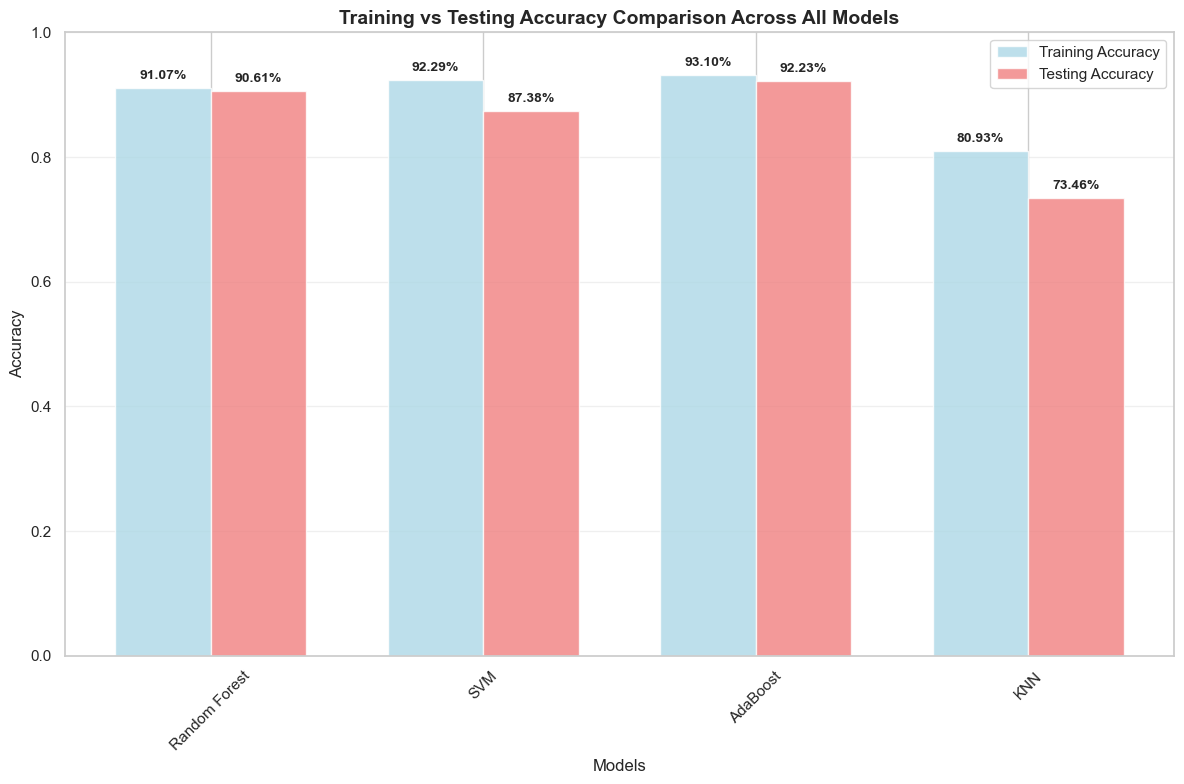


MODEL PERFORMANCE SUMMARY - TRAINING VS TESTING ACCURACY
Model           Training Acc    Testing Acc     Difference     
----------------------------------------------------------------------
Random Forest   0.9107          0.9061          +0.0046        
SVM             0.9229          0.8738          +0.0491        
AdaBoost        0.9310          0.9223          +0.0087        
KNN             0.8093          0.7346          +0.0746        


In [44]:
# Create comparison data
models = ['Random Forest', 'SVM', 'AdaBoost', 'KNN']
train_accuracies = [train_accuracy_rf, train_accuracy_svm, train_accuracy_adaboost, train_accuracy_knn]
test_accuracies = [test_accuracy_rf, test_accuracy_svm, test_accuracy_adaboost, test_accuracy_knn]

# Set up the plot
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 8))

# Create bars
bars1 = ax.bar(x - width/2, train_accuracies, width, label='Training Accuracy', color='lightblue', alpha=0.8)
bars2 = ax.bar(x + width/2, test_accuracies, width, label='Testing Accuracy', color='lightcoral', alpha=0.8)

# Add labels, title, and legend
ax.set_xlabel('Models')
ax.set_ylabel('Accuracy')
ax.set_title('Training vs Testing Accuracy Comparison Across All Models', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45)
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*70)
print("MODEL PERFORMANCE SUMMARY - TRAINING VS TESTING ACCURACY")
print("="*70)
print(f"{'Model':<15} {'Training Acc':<15} {'Testing Acc':<15} {'Difference':<15}")
print("-"*70)
for i, model in enumerate(models):
    train_acc = train_accuracies[i]
    test_acc = test_accuracies[i]
    diff = train_acc - test_acc
    diff_str = f"+{diff:.4f}" if diff > 0 else f"{diff:.4f}"
    print(f"{model:<15} {train_acc:<15.4f} {test_acc:<15.4f} {diff_str:<15}")
print("="*70)

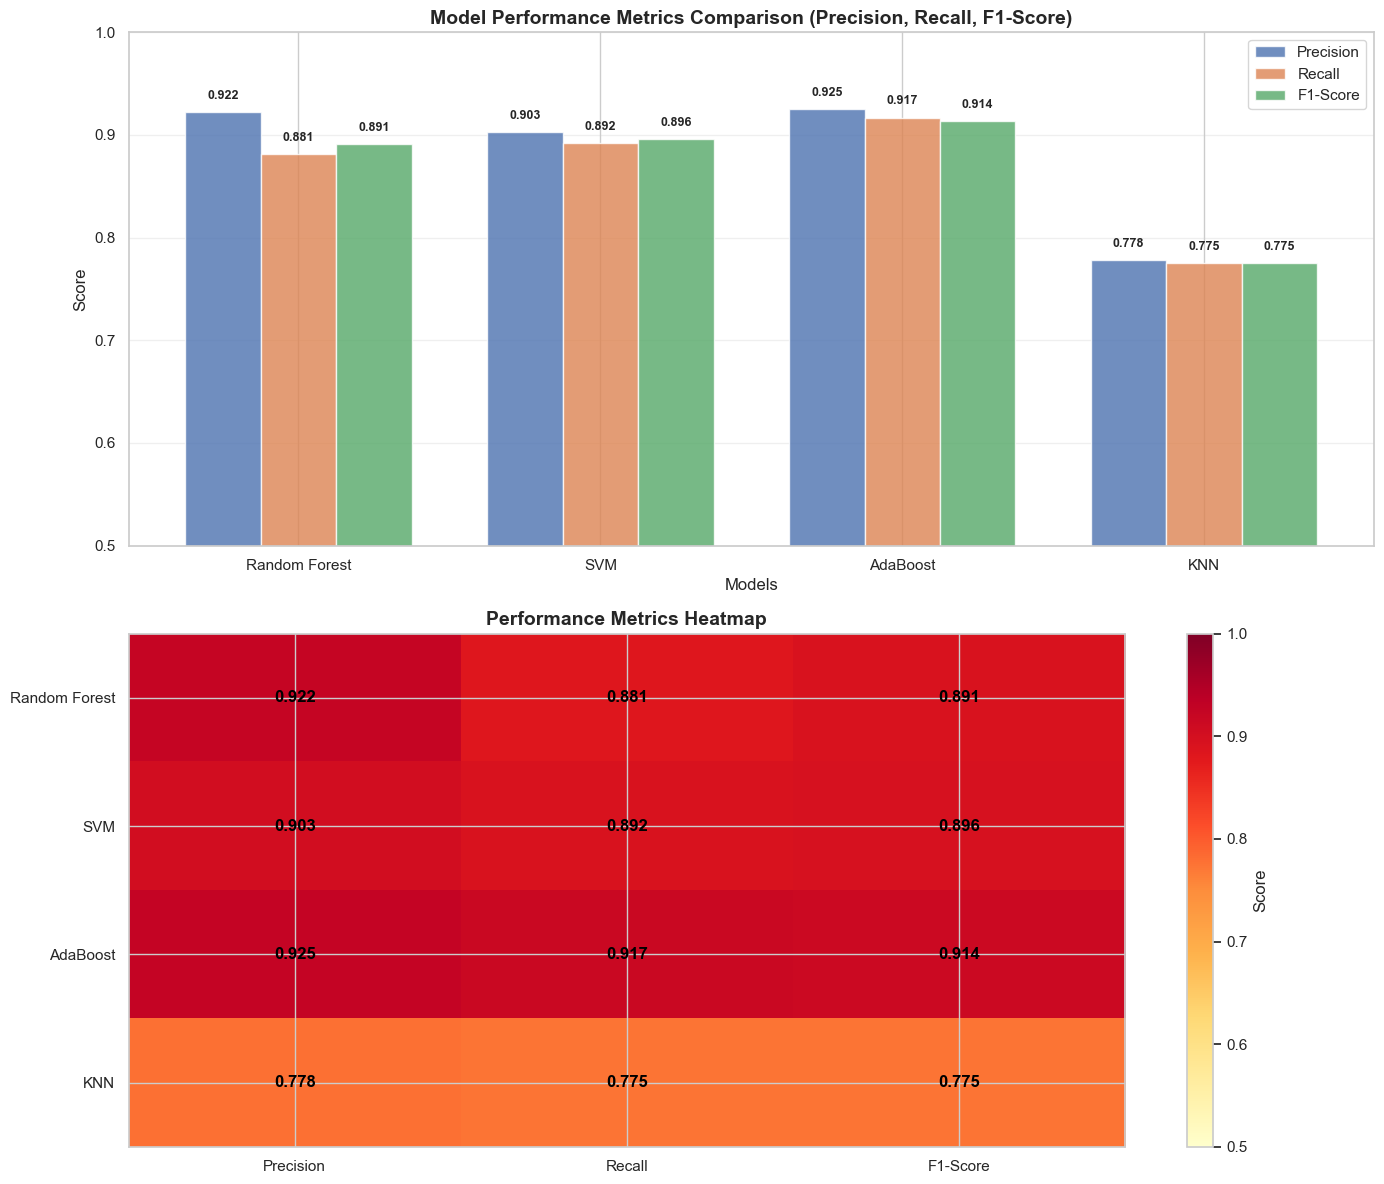


MODEL PERFORMANCE METRICS SUMMARY (Macro Averages)
Model           Precision    Recall       F1-Score    
--------------------------------------------------------------------------------
Random Forest   0.9225       0.8815       0.8908      
SVM             0.9030       0.8922       0.8958      
AdaBoost        0.9251       0.9169       0.9135      
KNN             0.7778       0.7753       0.7752      


In [45]:
# Calculate macro averages for each model
from sklearn.metrics import precision_score, recall_score, f1_score

def calculate_metrics(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    return {
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1-Score': f1_score(y_test, y_pred, average='macro')
    }

# Calculate metrics for all models
metrics_data = {
    'Random Forest': calculate_metrics(rf_model, X_test, y_test, "Random Forest"),
    'SVM': calculate_metrics(svm, X_test, y_test, "SVM"),
    'AdaBoost': calculate_metrics(adaboost_model, X_test, y_test, "AdaBoost"),
    'KNN': calculate_metrics(knn_clf, X_test, y_test, "KNN")
}

# Create the comparison plot
models = list(metrics_data.keys())
metrics_names = ['Precision', 'Recall', 'F1-Score']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Grouped bar chart
x = np.arange(len(models))
width = 0.25

for i, metric in enumerate(metrics_names):
    values = [metrics_data[model][metric] for model in models]
    ax1.bar(x + i*width, values, width, label=metric, alpha=0.8)

ax1.set_xlabel('Models')
ax1.set_ylabel('Score')
ax1.set_title('Model Performance Metrics Comparison (Precision, Recall, F1-Score)', 
              fontsize=14, fontweight='bold')
ax1.set_xticks(x + width)
ax1.set_xticklabels(models)
ax1.legend()
ax1.set_ylim(0.5, 1.0)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars for Plot 1
for i, metric in enumerate(metrics_names):
    values = [metrics_data[model][metric] for model in models]
    for j, value in enumerate(values):
        ax1.text(x[j] + i*width, value + 0.01, f'{value:.3f}', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Heatmap
metrics_matrix = np.array([[metrics_data[model][metric] for metric in metrics_names] 
                          for model in models])

im = ax2.imshow(metrics_matrix, cmap='YlOrRd', aspect='auto', vmin=0.5, vmax=1.0)

# Show all ticks and labels
ax2.set_xticks(np.arange(len(metrics_names)))
ax2.set_yticks(np.arange(len(models)))
ax2.set_xticklabels(metrics_names)
ax2.set_yticklabels(models)

# Add text annotations in heatmap
for i in range(len(models)):
    for j in range(len(metrics_names)):
        text = ax2.text(j, i, f'{metrics_matrix[i, j]:.3f}',
                       ha="center", va="center", color="black", fontweight='bold')

ax2.set_title('Performance Metrics Heatmap', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax2, label='Score')

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*80)
print("MODEL PERFORMANCE METRICS SUMMARY (Macro Averages)")
print("="*80)
print(f"{'Model':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*80)
for model in models:
    prec = metrics_data[model]['Precision']
    rec = metrics_data[model]['Recall']
    f1 = metrics_data[model]['F1-Score']
    print(f"{model:<15} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")
print("="*80)